In [1]:
"""Module for managing registered MLflow models based on performance metrics."""

from __future__ import annotations

import logging
from typing import Any, NamedTuple

import mlflow
from mlflow.exceptions import MlflowException
from mlflow.tracking import MlflowClient

logger = logging.getLogger(__name__)


class ModelVersionScore(NamedTuple):
    """Container for model version metadata and its evaluated metric score."""

    name: str
    version: str
    run_id: str
    score: float


def get_and_promote_best_model(
    model_name: str,
    metric_name: str = "f1_score",
    alias: str = "champion",
    tracking_uri: str | None = None,
) -> ModelVersionScore | None:
    """Finds the registered model version with the highest metric score and updates its alias.

    Args:
        model_name: Name of the registered model in the MLflow Model Registry.
        metric_name: Name of the evaluation metric to maximize (e.g., "f1_score").
        alias: The MLflow alias to assign to the top-performing model (default: "champion").
        tracking_uri: Optional MLflow tracking server URI. If None, uses default context.

    Returns:
        ModelVersionScore containing details of the promoted model, or None if no valid
        model versions with the metric were found.

    Raises:
        MlflowException: If the MLflow API encounters an unhandled error.
    """
    if tracking_uri:
        mlflow.set_tracking_uri(tracking_uri)

    client = MlflowClient()
    logger.info("Fetching registered model versions for: %s", model_name)

    try:
        model_versions = client.search_model_versions(f"name='{model_name}'")
    except MlflowException as err:
        logger.error("Failed to retrieve model versions for '%s': %s", model_name, err)
        raise

    if not model_versions:
        logger.warning("No registered model versions found for '%s'.", model_name)
        return None

    best_model: ModelVersionScore | None = None

    for mv in model_versions:
        try:
            run = client.get_run(mv.run_id)
            metric_val = run.data.metrics.get(metric_name)

            if metric_val is None:
                logger.debug(
                    "Metric '%s' not found for model '%s' v%s (run_id: %s). Skipping.",
                    metric_name,
                    model_name,
                    mv.version,
                    mv.run_id,
                )
                continue

            if best_model is None or metric_val > best_model.score:
                best_model = ModelVersionScore(
                    name=model_name,
                    version=str(mv.version),
                    run_id=mv.run_id,
                    score=float(metric_val),
                )
        except MlflowException as err:
            logger.warning(
                "Could not fetch run metadata for version %s (run_id: %s): %s",
                mv.version,
                mv.run_id,
                err,
            )

    if best_model is None:
        logger.warning(
            "No version of '%s' had a valid metric logged for '%s'.",
            model_name,
            metric_name,
        )
        return None

    # Promote the top performer using MLflow Aliases (v2.0+)
    logger.info(
        "Promoting '%s' v%s as '%s' (Highest %s: %.4f)",
        best_model.name,
        best_model.version,
        alias,
        metric_name,
        best_model.score,
    )
    client.set_registered_model_alias(
        name=best_model.name,
        alias=alias,
        version=best_model.version,
    )

    return best_model


if __name__ == "__main__":
    logging.basicConfig(level=logging.INFO)

    # Example Usage
    MODEL_NAME = "open_food_lightgbm"
    RESULT = get_and_promote_best_model(
        model_name=MODEL_NAME,
        metric_name="macro_f1",
        alias="champion",
        tracking_uri="sqlite:///../mlflow.db"
    )

    if RESULT:
        print(f"Successfully assigned 'champion' alias to version {RESULT.version} with F1={RESULT.score:.4f}")
    else:
        print("Model promotion task completed with no candidate promoted.")

/mnt/work/open_food_mlops/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:__main__:Fetching registered model versions for: open_food_lightgbm
INFO:__main__:Promoting 'open_food_lightgbm' v2 as 'champion' (Highest macro_f1: 0.7009)


Successfully assigned 'champion' alias to version 2 with F1=0.7009


In [6]:
RESULT

ModelVersionScore(name='open_food_lightgbm', version='2', run_id='f42abe06ca954d6a89bf2f45659b5622', score=0.7009353496110527)

In [2]:
"""Module for fetching and listing registered models from MLflow Model Registry."""

from __future__ import annotations

import logging
from typing import Any, Dict, List, Optional

import mlflow
from mlflow.exceptions import MlflowException
from mlflow.tracking import MlflowClient

logger = logging.getLogger(__name__)


def get_registered_models(
    model_name: Optional[str] = None,
    tracking_uri: Optional[str] = None,
) -> List[Dict[str, Any]]:
    """Retrieves registered models and their version metadata from MLflow.

    Args:
        model_name: Optional name of a specific registered model. If None, fetches
            all registered models in the registry.
        tracking_uri: Optional MLflow tracking server URI. If None, uses default context.

    Returns:
        A list of dictionaries containing model metadata and associated version details.

    Raises:
        MlflowException: If MLflow server communication fails.
    """
    if tracking_uri:
        mlflow.set_tracking_uri(tracking_uri)

    client = MlflowClient()
    models_summary: List[Dict[str, Any]] = []

    try:
        if model_name:
            # Fetch single specific model
            registered_models = [client.get_registered_model(model_name)]
        else:
            # Search all registered models
            registered_models = list(client.search_registered_models())

        for rm in registered_models:
            versions = client.search_model_versions(f"name='{rm.name}'")
            version_details = [
                {
                    "version": mv.version,
                    "stage": mv.current_stage,
                    "aliases": mv.aliases,
                    "run_id": mv.run_id,
                    "status": mv.status,
                    "creation_timestamp": mv.creation_timestamp,
                }
                for mv in versions
            ]

            models_summary.append(
                {
                    "name": rm.name,
                    "latest_versions": [mv.version for mv in rm.latest_versions],
                    "aliases": rm.aliases,
                    "tags": rm.tags,
                    "versions": version_details,
                }
            )

    except MlflowException as err:
        logger.error("Failed to retrieve registered models from MLflow: %s", err)
        raise

    return models_summary


if __name__ == "__main__":
    logging.basicConfig(level=logging.INFO)

    # Example 1: Fetch all registered models
    all_models = get_registered_models(tracking_uri="sqlite:///../mlflow.db")
    print(f"Total Registered Models Found: {len(all_models)}")
    for m in all_models:
        print(f"Model: {m['name']} | Aliases: {m['aliases']} | Versions Count: {len(m['versions'])}")

    # Example 2: Fetch specific model if required
    # target_model = get_registered_models(model_name="food_classification_model")

Total Registered Models Found: 5
Model: open_food_decision_tree | Aliases: {} | Versions Count: 3
Model: open_food_lightgbm | Aliases: {'champion': 2} | Versions Count: 3
Model: open_food_logistic_regression | Aliases: {} | Versions Count: 2
Model: open_food_random_forest | Aliases: {} | Versions Count: 3
Model: open_food_xgboost | Aliases: {} | Versions Count: 2


In [3]:
"""Module for loading logged and registered MLflow models into memory."""

from __future__ import annotations

from typing import Any

import mlflow.sklearn


def load_model_by_run_id(
    run_id: str,
    artifact_path: str = "model",
) -> Any:
    """Load a trained model into memory using its MLflow Run ID.

    Args:
        run_id: The unique MLflow run identifier string.
        artifact_path: The name/artifact path assigned when logging the model.

    Returns:
        The deserialized Python model object ready for inference.
    """
    model_uri = f"runs:/{run_id}/{artifact_path}"
    model: Any = mlflow.sklearn.load_model(model_uri)
    return model


def load_model_by_registry_name(
    registered_model_name: str,
    version_or_alias: str = "latest",
) -> Any:
    """Load a registered model into memory from the MLflow Model Registry.

    Args:
        registered_model_name: The target registered model name in the registry.
        version_or_alias: Model version number (e.g., "1") or alias (e.g., "Champion", "latest").

    Returns:
        The deserialized Python model object ready for inference.
    """
    model_uri = f"models:/{registered_model_name}/{version_or_alias}"
    model: Any = mlflow.sklearn.load_model(model_uri)
    return model


# Usage Example
if __name__ == "__main__":
    # Ensure tracking URI matches your environment configuration
    mlflow.set_tracking_uri("sqlite:///../mlflow.db")

    # Option A: Load using Run ID
    run_id = RESULT.run_id  # Replace with your actual run_id
    #model_from_run = load_model_by_run_id(run_id=run_id, artifact_path="../mlruns/")
    # predictions = model_from_run.predict(X_test)

    # Option B: Load using Model Registry Name
    registered_name = RESULT.name
    model_from_registry = load_model_by_registry_name(
        registered_model_name=registered_name,
        version_or_alias="3",
    )
    # predictions = model_from_registry.predict(X_test)

INFO:open_food_mlops.models.registry:Registered model decision_tree from open_food_mlops.models.implementations.decision_tree
INFO:open_food_mlops.models.registry:Registered model lightgbm from open_food_mlops.models.implementations.lightgbm
INFO:open_food_mlops.models.registry:Registered model logistic_regression from open_food_mlops.models.implementations.logistic_regression
INFO:open_food_mlops.models.registry:Registered model random_forest from open_food_mlops.models.implementations.random_forest
INFO:open_food_mlops.models.registry:Registered model xgboost from open_food_mlops.models.implementations.xgboost


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

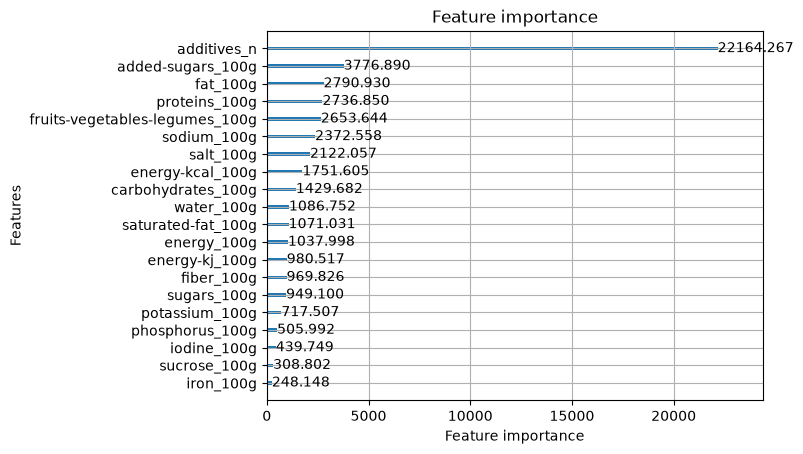

In [10]:
import lightgbm as lgb

# Assuming 'model' is your trained LGBMClassifier or LGBMRegressor
# Get raw importance values as an array
model = model_from_registry.estimator_
split_importance = model.feature_importances_  # default is 'split'
gain_importance = model.booster_.feature_importance(importance_type="gain")

# Plot feature importance directly
lgb.plot_importance(model, importance_type="gain", max_num_features=20)


In [18]:
df.drop(columns=["code", "product_name"]).to_parquet("../data/processed/processed_data.parquet", index=False)

In [ ]:
for col in [
            #"nova_group",
            "added-sugars_100g",
            "fat_100g",
            "proteins_100g",
            "fruits-vegetables-legumes_100g",
            "sodium_100g",
            "salt_100g",
            "energy-kcal_100g",
            "carbohydrates_100g",
            "water_100g",
            "saturated-fat_100g",
            
]:
    assert col in model.feature_name_, f"Column {col} not found in features"